# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [85]:
import pandas as pd
import seaborn as sns
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy.io import loadmat

from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, VotingRegressor, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost
from sklearn.svm import SVC, LinearSVC

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [86]:
data = loadmat("data/ejer_1_data1.mat")
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:43 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[1.9643  , 4.5957  ],
        [2.2753  , 3.8589  ],
        [2.9781  , 4.5651  ],
        [2.932   , 3.5519  ],
        [3.5772  , 2.856   ],
        [4.015   , 3.1937  ],
        [3.3814  , 3.4291  ],
        [3.9113  , 4.1761  ],
        [2.7822  , 4.0431  ],
        [2.5518  , 4.6162  ],
        [3.3698  , 3.9101  ],
        [3.1048  , 3.0709  ],
        [1.9182  , 4.0534  ],
        [2.2638  , 4.3706  ],
        [2.6555  , 3.5008  ],
        [3.1855  , 4.2888  ],
        [3.6579  , 3.8692  ],
        [3.9113  , 3.4291  ],
        [3.6002  , 3.1221  ],
        [3.0357  , 3.3165  ],
        [1.5841  , 3.3575  ],
        [2.0103  , 3.2039  ],
        [1.9527  , 2.7843  ],
        [2.2753  , 2.7127  ],
        [2.3099  , 2.9584  ],
        [2.8283  , 2.6309  ],
        [3.0473  , 2.2931  ],
        [2.4827  , 2.0373  ],
        [2.5057 

In [87]:
X = data["X"]
y = data["y"]

In [88]:
df = pd.DataFrame(X, columns=["col1", "col2"])
df["target"] = y
df.head()


,col1,col2,target
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    51 non-null     float64
 1   col2    51 non-null     float64
 2   target  51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [90]:
df.describe()

,col1,col2,target
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


In [91]:
df["target"].value_counts()

target
0    30
1    21
Name: count, dtype: int64

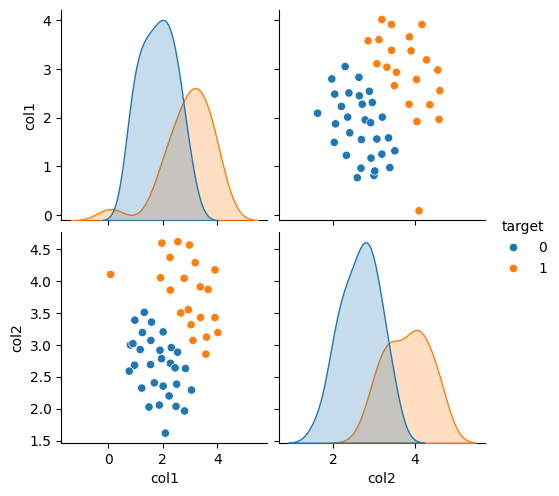

In [92]:
sns.pairplot(df, hue="target")

<Axes: >

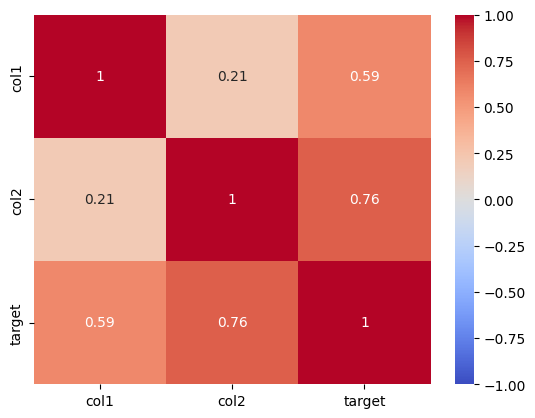

In [93]:
sns.heatmap(df.corr(), annot=True, vmin=-1, cmap="coolwarm")

#### 3. Create a DataFrame with the features and target

In [94]:
X = df[["col1", "col2"]]
y = df["target"]

#### 4. Plot a scatterplot with the data

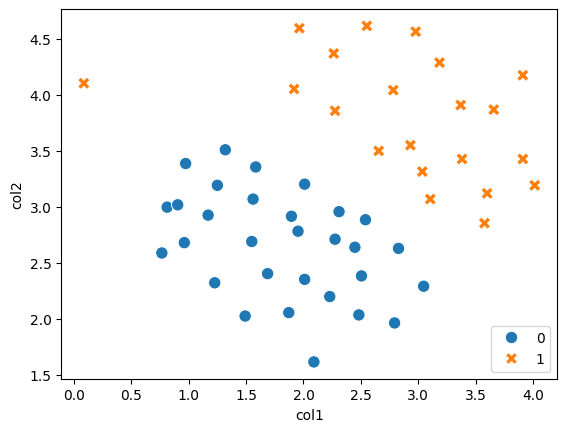

In [95]:
sns.scatterplot(data=df, x="col1", y="col2", hue="target", style="target", s=80)
plt.legend(loc="lower right")

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [96]:
lsvm_clf = LinearSVC(C=1, loss='hinge', max_iter=10000)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lsvm_clf.fit(X_scaled, y)

,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001
,C,1
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


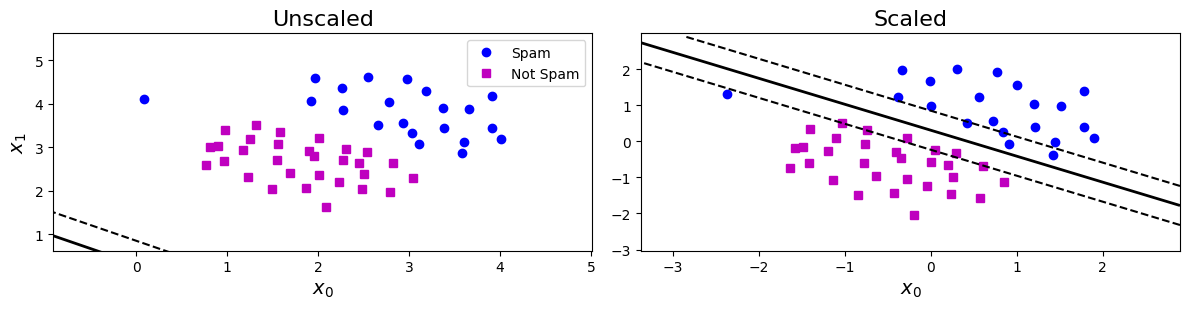

In [97]:
def plot_svc_decision_boundary(model, xmin, xmax):
    # Crear malla
    xx = np.linspace(xmin, xmax, 500)
    yy = np.linspace(xmin, xmax, 500)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.c_[XX.ravel(), YY.ravel()]
    
    # Función de decisión
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # Frontera y márgenes
    plt.contour(XX, YY, Z, levels=[0], linewidths=2, colors='k')
    plt.contour(XX, YY, Z, levels=[-1, 1], linestyles='--', colors='k')

y_flat = y  # convierte tu columna target a Series 1D

plt.figure(figsize=(12,3.2))
plt.subplot(121)
plt.plot(X["col1"][y_flat==1], X["col2"][y_flat==1], "bo", label="Spam")
plt.plot(X["col1"][y_flat==0], X["col2"][y_flat==0], "ms", label="Not Spam")
plot_svc_decision_boundary(lsvm_clf, X["col1"].min()-1, X["col1"].max()+1)
plt.xlabel("$x_0$", fontsize=14)
plt.ylabel("$x_1$", fontsize=14)
plt.title("Unscaled", fontsize=16)
plt.legend()
plt.axis([X["col1"].min()-1, X["col1"].max()+1, X["col2"].min()-1, X["col2"].max()+1])

# Datos escalados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svm_clf_scaled = LinearSVC(C=1, loss='hinge', max_iter=10000)
svm_clf_scaled.fit(X_scaled, y_flat)

plt.subplot(122)
plt.plot(X_scaled[:, 0][y_flat==1], X_scaled[:, 1][y_flat==1], "bo", label="Spam")
plt.plot(X_scaled[:, 0][y_flat==0], X_scaled[:, 1][y_flat==0], "ms", label="Not Spam")
plot_svc_decision_boundary(svm_clf_scaled, X_scaled[:,0].min()-1, X_scaled[:,0].max()+1)
plt.xlabel("$x_0$", fontsize=14)
plt.title("Scaled", fontsize=16)
plt.axis([X_scaled[:,0].min()-1, X_scaled[:,0].max()+1, X_scaled[:,1].min()-1, X_scaled[:,1].max()+1])

plt.tight_layout()
plt.show()


#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [98]:
pred_lsvm = lsvm_clf.predict(X_scaled)

print("Accuracy:", accuracy_score(y, pred_lsvm))
print("Confusion matrix:\n", confusion_matrix(y, pred_lsvm))

Accuracy: 0.9803921568627451
Confusion matrix:
 [[30  0]
 [ 1 20]]


<Axes: >

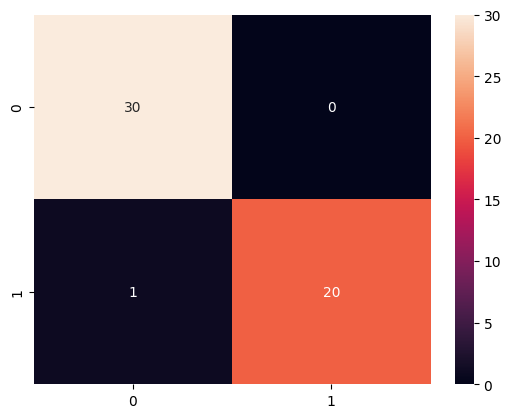

In [99]:
c_matrix = confusion_matrix(y, pred_lsvm)
sns.heatmap(c_matrix, annot=True, vmin=0)

It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [100]:
parametros = {"C": np.logspace(-2, 3, 10)}  

grid_lsvm = GridSearchCV(lsvm_clf, param_grid=parametros, cv=10, scoring="accuracy", verbose=3)

grid_lsvm.fit(X_scaled, y)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV 1/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 2/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 3/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 4/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 5/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 6/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 7/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 8/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 9/10] END ...........................C=0.01;, score=1.000 total time=   0.0s
[CV 10/10] END ..........................C=0.01;, score=0.800 total time=   0.0s
[CV 1/10] END ............C=0.03593813663804628;, score=1.000 total time=   0.0s
[CV 2/10] END ............C=0.0359381366380462

,estimator,LinearSVC(C=1...ax_iter=10000)
,param_grid,{'C': array([1.0000...00000000e+03])}
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [101]:
print(grid_lsvm.best_estimator_)
print(grid_lsvm.best_score_)

LinearSVC(C=np.float64(0.01), loss='hinge', max_iter=10000)
0.9800000000000001


This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [102]:
valores_decision = grid_lsvm.decision_function(X_scaled)
valores_decision

array([ 0.55646022,  0.28134599,  0.86505895,  0.33525632,  0.18779143,
        0.49944499,  0.41652266,  0.96569303,  0.53706163,  0.75472979,
        0.6573311 ,  0.14599028,  0.26604068,  0.53779281,  0.2208709 ,
        0.79091568,  0.72865713,  0.58595388,  0.33041803,  0.24874743,
       -0.19454743, -0.13635635, -0.3680781 , -0.30132739, -0.16536217,
       -0.16609335, -0.26779128, -0.57835405, -0.3940934 , -0.76321806,
       -0.56809994, -0.83419213, -0.31883354, -0.34762723, -0.54376643,
       -0.64523989, -0.90033949, -0.73685081, -0.545717  , -0.6234988 ,
       -0.37422623, -0.38464129, -0.20129778, -0.57619135, -0.28244205,
       -0.51533122, -0.91690156, -0.1281425 , -0.58354654, -0.8462915 ,
       -0.29368408])

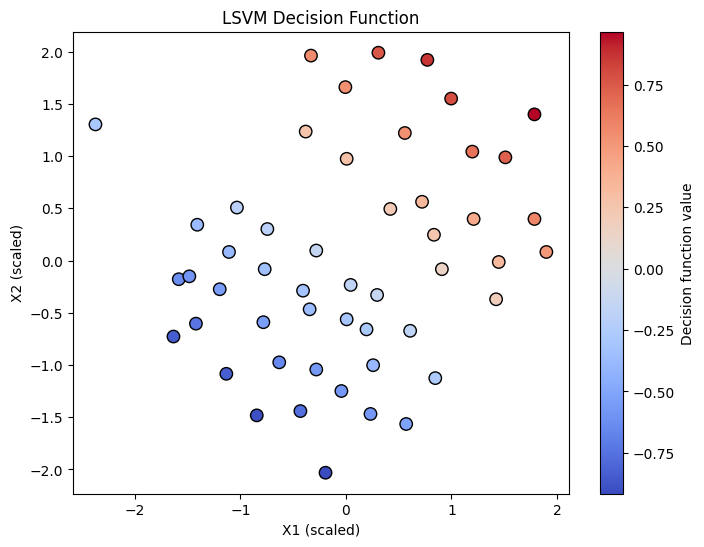

In [103]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], 
    c=valores_decision,             
    cmap='coolwarm',                
    s=80,                           
    edgecolors='k'
)

plt.colorbar(label='Decision function value')
plt.xlabel("X1 (scaled)")
plt.ylabel("X2 (scaled)")
plt.title("LSVM Decision Function")
plt.show()

#### 9. Do the same with the second model (SVM)

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

In [104]:
svm_clf = SVC(kernel = "poly", degree=10, coef0=100, C=5)

svm_clf.fit(X_scaled, y)

,C,5
,kernel,'poly'
,degree,10
,gamma,'scale'
,coef0,100
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


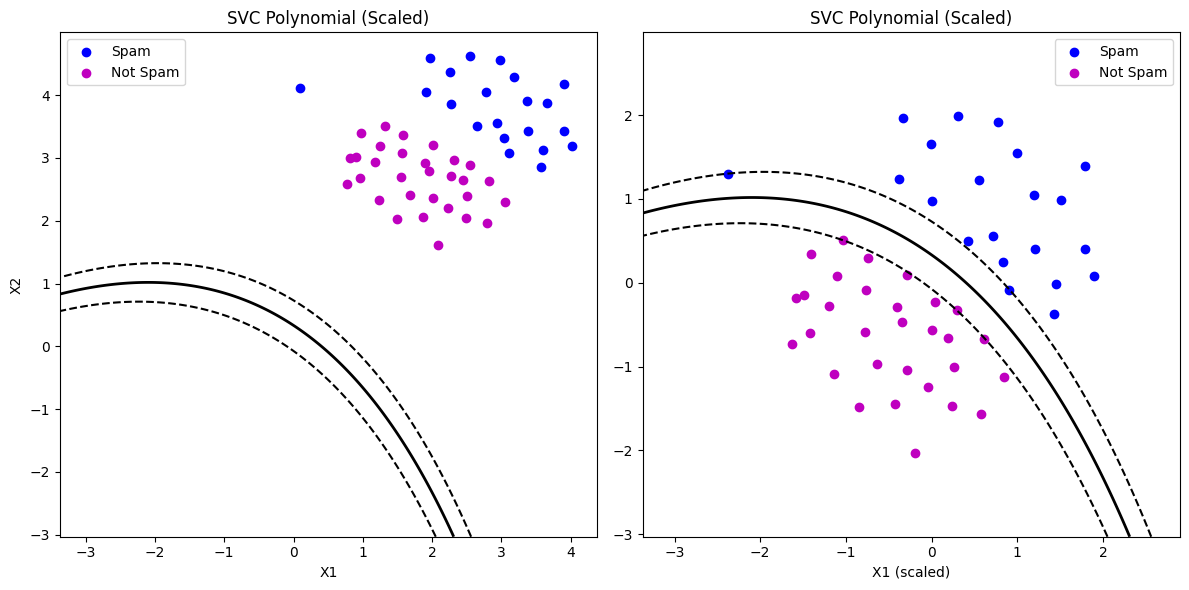

In [105]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Función para graficar frontera y márgenes ---
def plot_svc_decision_boundary(model, xmin, xmax, ymin, ymax):
    # Crear malla de puntos
    xx = np.linspace(xmin, xmax, 500)
    yy = np.linspace(ymin, ymax, 500)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.c_[XX.ravel(), YY.ravel()]
    
    # Calcular la función de decisión
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # Graficar frontera (nivel 0) y márgenes (niveles -1 y 1)
    plt.contour(XX, YY, Z, levels=[0], linewidths=2, colors='k')
    plt.contour(XX, YY, Z, levels=[-1, 1], linestyles='--', colors='k')

# --- Modelo SVC polinomial ---
svm_clf = SVC(kernel="poly", degree=10, coef0=100, C=5)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Escalado para SVC polinomial
svm_clf.fit(X_scaled, y.values.ravel())

# --- Scatterplot con SVC polinomial ---
plt.figure(figsize=(12, 6))

# Datos no escalados (simple visualización)
plt.subplot(121)
plt.scatter(X["col1"][y.values.ravel()==1], X["col2"][y.values.ravel()==1], color="b", label="Spam")
plt.scatter(X["col1"][y.values.ravel()==0], X["col2"][y.values.ravel()==0], color="m", label="Not Spam")
plot_svc_decision_boundary(svm_clf, X_scaled[:,0].min()-1, X_scaled[:,0].max()+1,
                           X_scaled[:,1].min()-1, X_scaled[:,1].max()+1)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVC Polynomial (Scaled)")
plt.legend()

# Datos escalados
plt.subplot(122)
plt.scatter(X_scaled[:,0][y.values.ravel()==1], X_scaled[:,1][y.values.ravel()==1], color="b", label="Spam")
plt.scatter(X_scaled[:,0][y.values.ravel()==0], X_scaled[:,1][y.values.ravel()==0], color="m", label="Not Spam")
plot_svc_decision_boundary(svm_clf, X_scaled[:,0].min()-1, X_scaled[:,0].max()+1,
                           X_scaled[:,1].min()-1, X_scaled[:,1].max()+1)
plt.xlabel("X1 (scaled)")
plt.title("SVC Polynomial (Scaled)")
plt.legend()

plt.tight_layout()
plt.show()


In [106]:
pred_svm = svm_clf.predict(X_scaled)

print("Accuracy:", accuracy_score(y, pred_svm))
print("Confusion matrix:\n", confusion_matrix(y, pred_svm))

Accuracy: 1.0
Confusion matrix:
 [[30  0]
 [ 0 21]]


<Axes: >

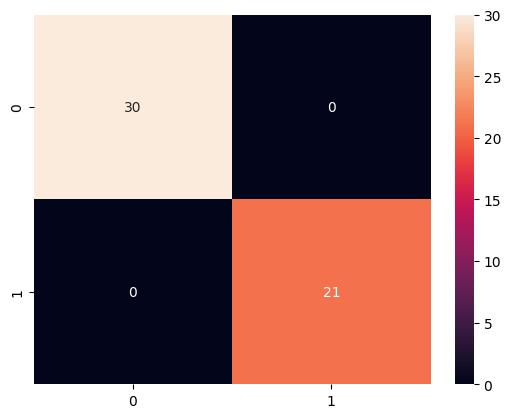

In [107]:
c_matrix_02 = confusion_matrix(y, pred_svm)
sns.heatmap(c_matrix_02, annot=True, vmin=0)

In [108]:
svm_clf_gauss = SVC(kernel="rbf", C=5, gamma='scale')  
svm_clf_gauss.fit(X_scaled, y)

,C,5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


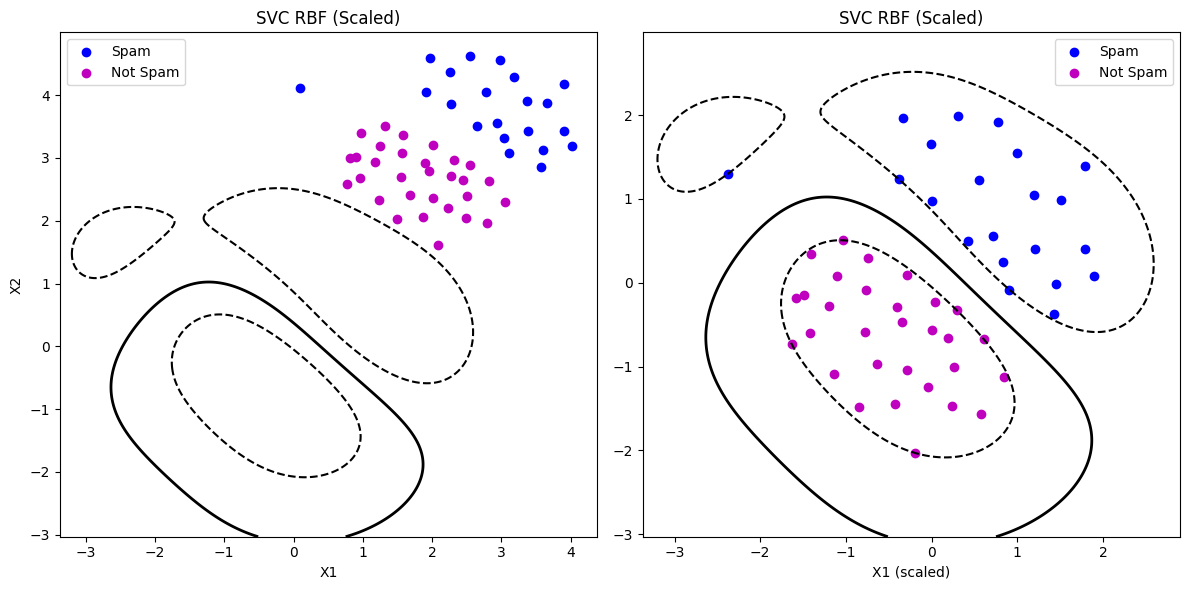

In [109]:
# --- Función para graficar frontera y márgenes ---
def plot_svc_decision_boundary(model, xmin, xmax, ymin, ymax):
    xx = np.linspace(xmin, xmax, 500)
    yy = np.linspace(ymin, ymax, 500)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.c_[XX.ravel(), YY.ravel()]
    
    Z = model.decision_function(xy).reshape(XX.shape)
    
    plt.contour(XX, YY, Z, levels=[0], linewidths=2, colors='k')
    plt.contour(XX, YY, Z, levels=[-1, 1], linestyles='--', colors='k')

# --- Modelo SVC RBF ---
svm_clf_rbf = SVC(kernel="rbf", C=5, gamma='scale')  # kernel gaussiano
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
svm_clf_rbf.fit(X_scaled, y.values.ravel())

# --- Scatterplot con SVC RBF ---
plt.figure(figsize=(12, 6))

# Datos no escalados (visualización)
plt.subplot(121)
plt.scatter(X["col1"][y.values.ravel()==1], X["col2"][y.values.ravel()==1], color="b", label="Spam")
plt.scatter(X["col1"][y.values.ravel()==0], X["col2"][y.values.ravel()==0], color="m", label="Not Spam")
plot_svc_decision_boundary(svm_clf_rbf, X_scaled[:,0].min()-1, X_scaled[:,0].max()+1,
                           X_scaled[:,1].min()-1, X_scaled[:,1].max()+1)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("SVC RBF (Scaled)")
plt.legend()

# Datos escalados
plt.subplot(122)
plt.scatter(X_scaled[:,0][y.values.ravel()==1], X_scaled[:,1][y.values.ravel()==1], color="b", label="Spam")
plt.scatter(X_scaled[:,0][y.values.ravel()==0], X_scaled[:,1][y.values.ravel()==0], color="m", label="Not Spam")
plot_svc_decision_boundary(svm_clf_rbf, X_scaled[:,0].min()-1, X_scaled[:,0].max()+1,
                           X_scaled[:,1].min()-1, X_scaled[:,1].max()+1)
plt.xlabel("X1 (scaled)")
plt.title("SVC RBF (Scaled)")
plt.legend()

plt.tight_layout()
plt.show()


In [110]:
pred_svm_gauss = svm_clf_gauss.predict(X_scaled)

print("Accuracy:", accuracy_score(y, pred_svm_gauss))
print("Confusion matrix:\n", confusion_matrix(y, pred_svm_gauss))

Accuracy: 1.0
Confusion matrix:
 [[30  0]
 [ 0 21]]


<Axes: >

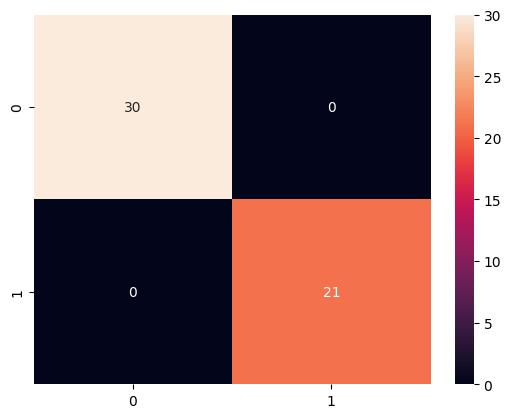

In [111]:
c_matrix_03 = confusion_matrix(y, pred_svm_gauss)
sns.heatmap(c_matrix_03, annot=True, vmin=0)

In [112]:
parametros_02 = {"C": np.logspace(-2, 3, 10)}  

grid_svm_gauss = GridSearchCV(svm_clf_gauss, param_grid=parametros_02, cv=10, scoring="accuracy", verbose=3)

grid_svm_gauss.fit(X_scaled, y)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV 1/10] END ...........................C=0.01;, score=0.500 total time=   0.0s
[CV 2/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 3/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 4/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 5/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 6/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 7/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 8/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 9/10] END ...........................C=0.01;, score=0.600 total time=   0.0s
[CV 10/10] END ..........................C=0.01;, score=0.600 total time=   0.0s
[CV 1/10] END ............C=0.03593813663804628;, score=0.500 total time=   0.0s
[CV 2/10] END ............C=0.0359381366380462

,estimator,SVC(C=5)
,param_grid,{'C': array([1.0000...00000000e+03])}
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(0.1291549665014884)


In [113]:
print(grid_svm_gauss.best_estimator_)
print(grid_svm_gauss.best_score_)

SVC(C=np.float64(0.1291549665014884))
0.9800000000000001


In [114]:
valores_decision_gauss = grid_svm_gauss.decision_function(X_scaled)
valores_decision_gauss

array([ 0.59172051,  0.51687595,  0.87271497,  0.75107269,  0.33637119,
        0.69826981,  0.86611983,  0.7758062 ,  0.98583803,  0.81774463,
        1.0639993 ,  0.2837297 ,  0.38193105,  0.77300578,  0.45701875,
        0.99981047,  1.00009476,  0.84910333,  0.64062785,  0.55637548,
       -0.71883287, -0.62030081, -1.08309914, -0.95470702, -0.67441766,
       -0.56063352, -0.62333167, -0.99990524, -0.99261637, -1.06229911,
       -1.1767185 , -1.00891146, -1.01242008, -1.01764229, -1.19014159,
       -1.181239  , -0.93833688, -1.02218877, -1.0947123 , -0.94942864,
       -0.7953815 , -0.96840801, -0.64849583, -1.11564473, -0.88672312,
       -0.840305  , -0.78499133, -0.54552707, -0.98485214, -0.89503703,
       -0.10121016])

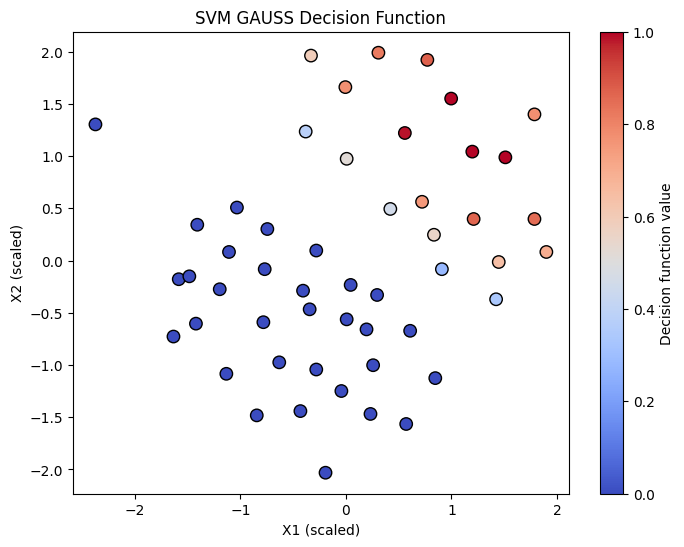

In [164]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1], 
    c=valores_decision_gauss,             
    cmap='coolwarm',                
    s=80,                           
    edgecolors='k',
    vmin=0, 
    vmax=1
)

plt.colorbar(label='Decision function value')
plt.xlabel("X1 (scaled)")
plt.ylabel("X2 (scaled)")
plt.title("SVM GAUSS Decision Function")
plt.show()

Now we're going to move from a linear SVM to one that's capable of non-linear classification using kernels.  We're first tasked with implementing a gaussian kernel function.  Although scikit-learn has a gaussian kernel built in, for transparency we'll implement one from scratch.

## Exercise 2

That result matches the expected value from the exercise.  Next we're going to examine another data set, this time with a non-linear decision boundary.

#### 1. Load the data `ejer_1_data2.mat`

In [116]:
data_02 = loadmat("data/ejer_1_data2.mat")
data_02

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sun Nov 13 14:28:54 2011',
 '__version__': '1.0',
 '__globals__': [],
 'X': array([[0.107143 , 0.60307  ],
        [0.093318 , 0.649854 ],
        [0.0979263, 0.705409 ],
        ...,
        [0.975806 , 0.439474 ],
        [0.989631 , 0.425439 ],
        [0.996544 , 0.414912 ]], shape=(863, 2)),
 'y': array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
    

#### 2. Create a DataFrame with the features and target

In [117]:
X2 = data_02["X"]
y2 = data_02["y"]

In [118]:
df_02 = pd.DataFrame(X2, columns=["col1", "col2"])
df_02["target"] = y2
df_02.head()

,col1,col2,target
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1


In [119]:
df_02.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    863 non-null    float64
 1   col2    863 non-null    float64
 2   target  863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [121]:
df_02["target"].value_counts()

target
1    480
0    383
Name: count, dtype: int64

#### 3. Plot a scatterplot with the data

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

In [122]:
svm_clf_gauss_02 = SVC(kernel="rbf", C=5, gamma='scale')  

scaler_02 = StandardScaler()
X_scaled_02 = scaler_02.fit_transform(X2)

svm_clf_gauss_02.fit(X_scaled_02, y2)


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,5
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


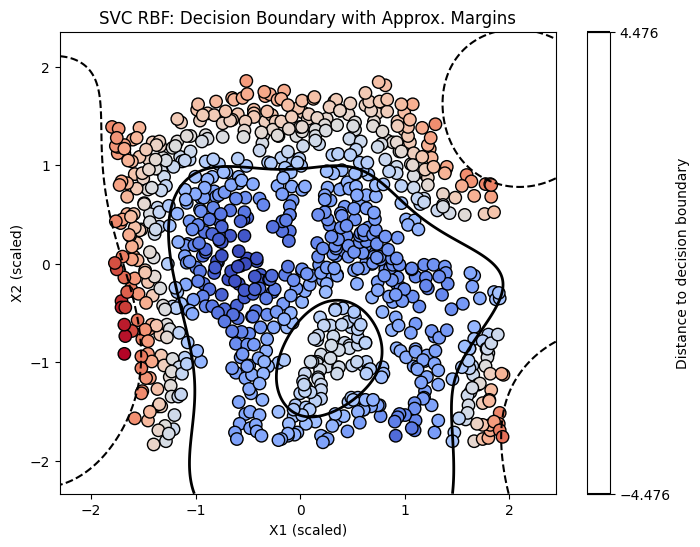

In [125]:
# --- Función para graficar frontera y márgenes ---
def plot_svc_rbf_boundary(model, X, ymin, ymax, xmin, xmax):
    # Crear malla
    xx = np.linspace(xmin, xmax, 500)
    yy = np.linspace(ymin, ymax, 500)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.c_[XX.ravel(), YY.ravel()]
    
    # Función de decisión
    Z = model.decision_function(xy).reshape(XX.shape)
    
    # Frontera (nivel 0)
    plt.contour(XX, YY, Z, levels=[0], linewidths=2, colors='k')
    
    # Márgenes aproximados (niveles ±0.5 de la media de valores extremos)
    margin = 0.5 * np.max(np.abs(Z))
    plt.contour(XX, YY, Z, levels=[-margin, margin], linestyles='--', colors='k')

# --- Scatterplot coloreado por distancia a la frontera ---
decision_values = svm_clf_gauss_02.decision_function(X_scaled_02)

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled_02[:, 0],
    X_scaled_02[:, 1],
    c=decision_values,
    cmap="coolwarm",
    s=80,
    edgecolors="k"
)

plot_svc_rbf_boundary(svm_clf_gauss_02, X_scaled_02,
                      ymin=X_scaled_02[:,1].min()-0.5,
                      ymax=X_scaled_02[:,1].max()+0.5,
                      xmin=X_scaled_02[:,0].min()-0.5,
                      xmax=X_scaled_02[:,0].max()+0.5)

plt.colorbar(label="Distance to decision boundary")
plt.xlabel("X1 (scaled)")
plt.ylabel("X2 (scaled)")
plt.title("SVC RBF: Decision Boundary with Approx. Margins")
plt.show()

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [130]:
svm_clf_gauss_03 = SVC(kernel="rbf", C=10, gamma=10, probability=True)  

#### 5. Fit the classifier and get the score

In [133]:
svm_clf_gauss_03.fit(X_scaled_02, y2)

pred_svm_clf_gauss_03 = svm_clf_gauss_03.predict(X_scaled_02)

print("Accuracy: ", accuracy_score(y2, pred_svm_clf_gauss_03))
print("\nMatriz de confusión:\n", confusion_matrix(y2, pred_svm_clf_gauss_03))
print("\nClassification report:\n", classification_report(y2, pred_svm_clf_gauss_03))

c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy:  0.9988412514484357

Matriz de confusión:
 [[383   0]
 [  1 479]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       383
           1       1.00      1.00      1.00       480

    accuracy                           1.00       863
   macro avg       1.00      1.00      1.00       863
weighted avg       1.00      1.00      1.00       863



<Axes: >

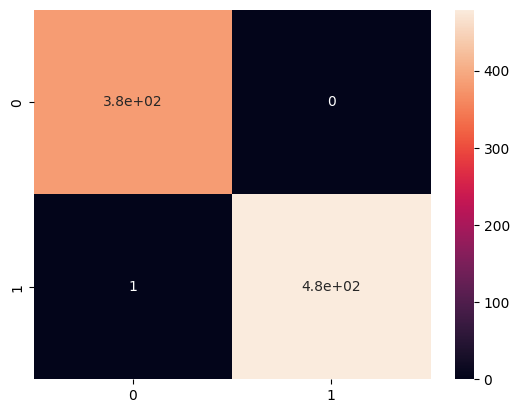

In [135]:
c_matrix_04 = confusion_matrix(y2, pred_svm_clf_gauss_03)
sns.heatmap(c_matrix_04, annot=True, vmin=0)

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [134]:
probabilidades = svm_clf_gauss_03.predict_proba(X_scaled_02)[:, 0]

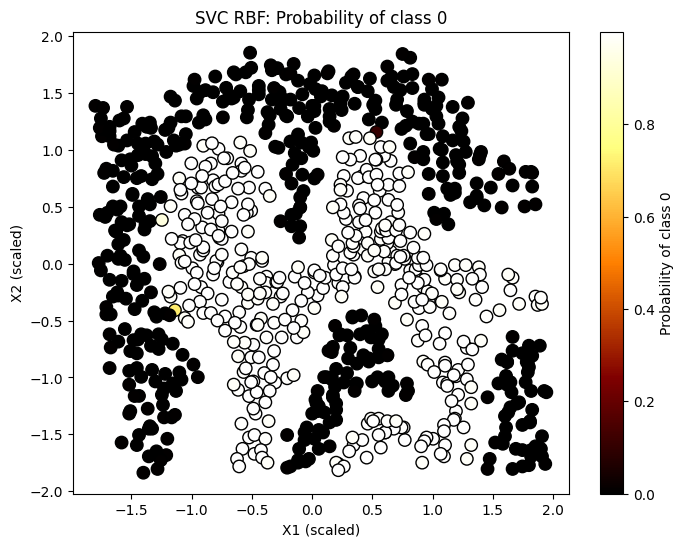

In [152]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled_02[:,0], X_scaled_02[:,1], c=probabilidades, cmap="afmhot", s=80, edgecolors="k")
plt.colorbar(label="Probability of class 0")
plt.xlabel("X1 (scaled)")
plt.ylabel("X2 (scaled)")
plt.title("SVC RBF: Probability of class 0")
plt.show()

#### Grid search

In [ ]:
parametros_03 = {"C": np.logspace(-2, 3, 10),
                 "gamma": np.logspace(-2, 1, 5)}  

grid_svm_gauss_02 = GridSearchCV(svm_clf_gauss_03, param_grid=parametros_03, cv=5, scoring="accuracy", verbose=3)

grid_svm_gauss_02.fit(X_scaled_02, y2)

In [156]:
print(grid_svm_gauss_02.best_estimator_)
print(grid_svm_gauss_02.best_score_)

SVC(C=np.float64(1.6681005372000592), gamma=np.float64(10.0), probability=True)
0.8756687726845007


In [159]:
valores_decision_gauss_02 = grid_svm_gauss_02.decision_function(X_scaled_02)
valores_decision_gauss_02 

array([ 1.34851169,  1.24364545,  1.34022002,  1.22530229,  1.41847233,
        1.40667978,  1.06559407,  1.45194144,  1.20974574,  1.08224566,
        1.23570687,  0.99992145,  1.45468077,  1.31969332,  1.25715267,
        1.36982426,  1.0002863 ,  1.04876474,  1.21655322,  1.09177083,
        1.3954277 ,  1.4350649 ,  1.71546773,  1.00010036,  1.03730182,
        1.45401722,  1.19307214,  1.11485149,  1.28824407,  1.25102358,
        0.72133021,  1.12734682,  1.37567578,  1.05198469,  0.99995577,
        1.23452225,  1.44351717,  1.5928676 ,  1.55968339,  1.58420709,
        1.44929192,  1.35121262,  1.21729003,  1.01082044,  1.00013943,
        1.10964548,  1.39589539,  1.48687332,  1.48341167,  1.389081  ,
        1.07566502,  1.01958204,  1.00051388,  1.69294078,  1.4444512 ,
        1.16122914,  1.04408358,  1.10838617,  1.24573896,  1.62018102,
        1.50991319,  1.3676437 ,  1.4501008 ,  1.43784948,  1.3119855 ,
        1.09131355,  1.07157301,  1.09682595,  1.39050411,  1.35

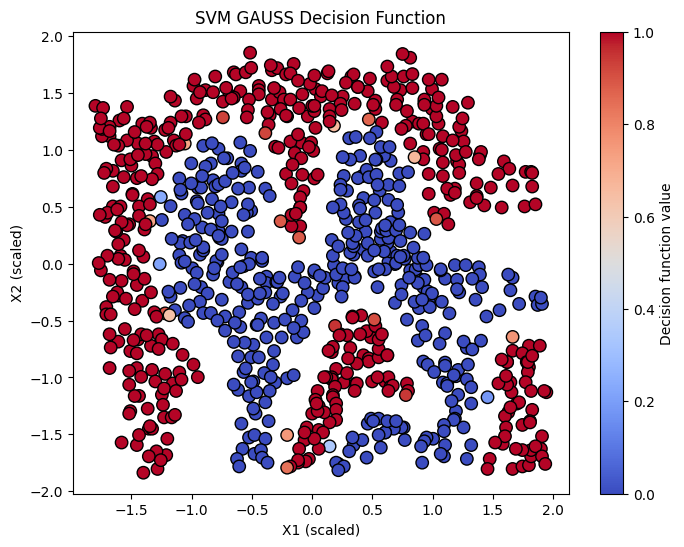

In [163]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled_02[:, 0], X_scaled_02[:, 1], 
    c=valores_decision_gauss_02,             
    cmap='coolwarm',                
    s=80,                           
    edgecolors='k', 
    vmin=0, 
    vmax=1
)

plt.colorbar(label='Decision function value')
plt.xlabel("X1 (scaled)")
plt.ylabel("X2 (scaled)")
plt.title("SVM GAUSS Decision Function")
plt.show()